**Research Question:** "What do self-reported accounts say about the benefits, duration, and adverse events of psilocybin, LSD, and ketamine?"

# Psychedelics: Strong Reports, Complicated Results

**Abstract.** In 2,921 self-reported actual-use claims, helpful effects were common, and a language-grading model identified 282 reporter accounts describing strong benefit. Psilocybin's clearest symptom-specific signal involved mood and cognitive symptoms, while LSD showed broadly positive but much thinner evidence. Benefit duration was usually omitted, and 49 accounts reported at least one extraction-defined severe adverse event. These findings describe selected online reports—not treatment efficacy, safety incidence, or medical advice.

**Data coverage:** source snapshot dated 2026-06-13; underlying post dates were not retained, so a content date range cannot be calculated.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

search_roots = [Path.cwd(), *Path.cwd().parents]
STUDY_DIR = next((p for p in search_roots if (p / "psychedelics_v2.py").exists()), None)
if STUDY_DIR is None:
    STUDY_DIR = next(p / "studies/psychedelics/v2" for p in search_roots if (p / "studies/psychedelics/v2/psychedelics_v2.py").exists())
sys.path.insert(0, str(STUDY_DIR))

import psychedelics_v2 as P

RUN_ID = "710567555e22b68c025d8ceb1c3373564d7f9b01dcc5fe94b02b7c3209ecbc05"
DB_PATH = P.db_path()
f = P.load_frames(DB_PATH, run_id=RUN_ID)
u = P.actual_use(f)
effects = u.effects.copy()

pair_directions = effects.groupby(["patient", "drug"])["direction"].agg(set)
def profile(directions):
    if directions == {"helped"}:
        return "Helped only"
    if directions == {"no_effect"}:
        return "No effect only"
    if directions == {"worsened"}:
        return "Worsened only"
    return "Mixed / conflicting"
profile_counts = pair_directions.map(profile).value_counts().reindex(
    ["Helped only", "Mixed / conflicting", "No effect only", "Worsened only"], fill_value=0
)

strong = effects[
    effects["magnitude_basis"].eq("model_rubric")
    & effects["direction"].eq("helped")
    & effects["magnitude"].ge(7)
]
strong_reporters = strong["patient"].nunique()
strong_by_drug = strong.groupby("drug")["patient"].nunique().reindex(P.DRUGS, fill_value=0)

benefit_duration = effects[
    effects["direction"].eq("helped") & effects["duration_bin"].notna()
].copy()
benefit_duration["duration_class"] = benefit_duration["duration_bin"].map(P.DURATION_LABELS)
duration_order = ["acute / short-lived", "intermediate", "long-lasting", "ongoing at report"]
duration_counts = benefit_duration["duration_class"].value_counts().reindex(duration_order, fill_value=0)

severe = u.adverse[u.adverse["severity"].eq("severe")]
severe_reporters = severe["patient"].nunique()
severe_categories = severe.groupby("category").agg(
    reporters=("patient", "nunique"), records=("claim_id", "size")
).sort_values("reporters", ascending=True)

P.apply_style(plt)
COLORS = ["#2b6cb0", "#805ad5", "#a0aec0", "#c53030"]

## Most accounts described benefit—but not benefit alone

The extraction contained **2,921 claims from 953 reporter–drug pairs**. Among the 747 pairs with an extractable effect, roughly six in seven described at least one helpful effect. The mutually exclusive profiles below show the complication: about one in five accounts described mixed or conflicting effects rather than an uncomplicated success.

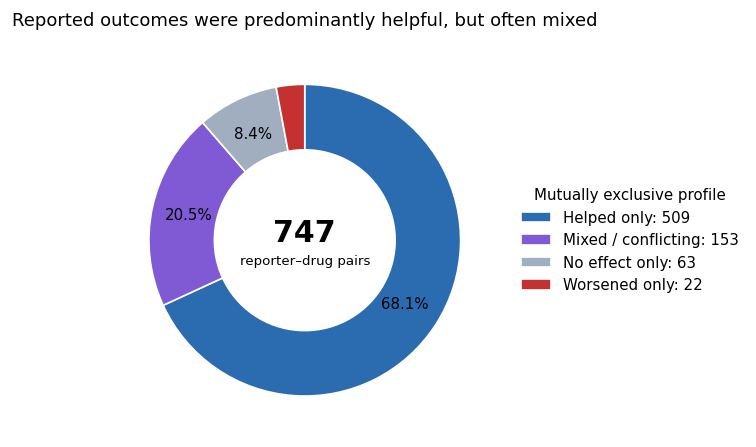

In [2]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
wedges, _, autotexts = ax.pie(
    profile_counts.values,
    colors=COLORS,
    startangle=90,
    counterclock=False,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
    pctdistance=0.76,
    wedgeprops={"width": 0.42, "edgecolor": "white"},
)
for text in autotexts:
    text.set_fontsize(9)
ax.text(0, 0.05, f"{profile_counts.sum():,}", ha="center", va="center", fontsize=18, weight="bold")
ax.text(0, -0.13, "reporter–drug pairs", ha="center", va="center", fontsize=8)
ax.legend(
    wedges,
    [f"{label}: {value:,}" for label, value in profile_counts.items()],
    title="Mutually exclusive profile",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)
ax.set_title("Reported outcomes were predominantly helpful, but often mixed", pad=12)
fig.tight_layout()
plt.show()

**Plain-language verdict:** Positive accounts dominated, but “reported any benefit” is not the same as “everything improved.” Thirty-five pairs contained both helped and worsened effects.

## Where the strongest reports appeared

The model graded the language in **282 unique accounts** as describing a helpful effect of 7–10 in magnitude: 148 psilocybin reporters, 118 ketamine reporters, and 22 LSD reporters. Six accounts contributed to more than one drug total. This is the model's interpretation of the wording—not a numeric score supplied by the reporter.

Psilocybin's clearest symptom-specific result involved **mood and cognitive symptoms**: 122 of 131 accounts (93.1%) reported help. Pain was also frequently described as helped (26 of 29; 89.7%), while general fatigue was less uniformly positive (17 of 23; 73.9%). LSD's mood/cognitive reports were positive, but only 15 accounts contributed to that cell, below the study's evidence threshold. Neither drug had enough explicit reports to support a conclusion about **post-exertional malaise (PEM)**.

## Duration: encouraging reports, major missingness

Only **235 helpful-effect records stated a duration**. “Acute” means during the session or under 24 hours; “intermediate” means one day to four weeks; and “long-lasting” means one month or more.

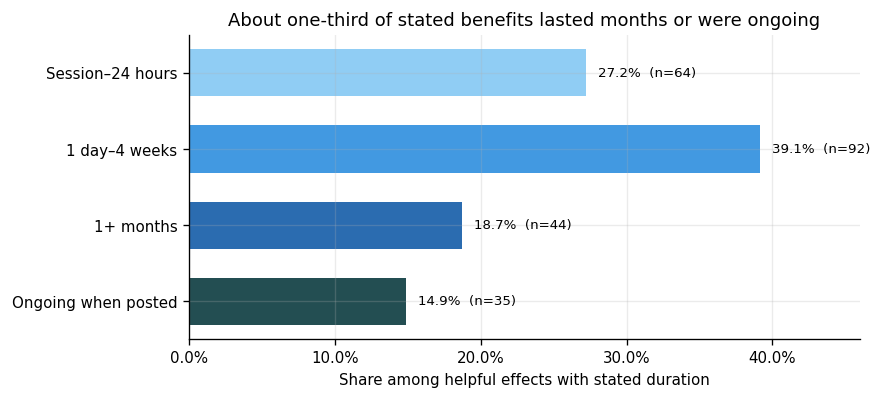

In [3]:
labels = ["Session–24 hours", "1 day–4 weeks", "1+ months", "Ongoing when posted"]
shares = duration_counts / duration_counts.sum()
fig, ax = plt.subplots(figsize=(7.4, 3.4))
y = np.arange(len(labels))
ax.barh(y, shares.values, color=["#90cdf4", "#4299e1", "#2b6cb0", "#234e52"], height=0.62)
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlim(0, 0.46)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
ax.set_xlabel("Share among helpful effects with stated duration")
ax.set_title("About one-third of stated benefits lasted months or were ongoing")
for yi, (share, count) in enumerate(zip(shares.values, duration_counts.values)):
    ax.text(share + 0.008, yi, f"{share:.1%}  (n={count})", va="center", fontsize=8)
fig.tight_layout()
plt.show()

**Plain-language verdict:** Among benefits with a stated duration, 27.2% ended during the session or within 24 hours, 39.1% lasted one day to four weeks, 18.7% lasted at least a month, and 14.9% were ongoing. But **90.9% of all effect records omitted duration**, so this cannot estimate how often benefits persist.

## Counterintuitive finding worth investigating

The broadly positive picture did not extend evenly across symptoms. General fatigue attracted less helped-reporting than mood/cognitive symptoms, with the sharpest deficit under ketamine. This is a fatigue result—not a PEM result—and it argues against treating “energy,” “fatigue,” and post-exertional worsening as interchangeable outcomes.

## Severe adverse events

Across all three drugs, **49 reporter accounts** described at least one event that the extraction rubric graded severe, producing 98 severe-event records. “Severe” meant medical care, danger, major persistent impairment, or stopping treatment; it was not a clinically adjudicated regulatory serious adverse event.

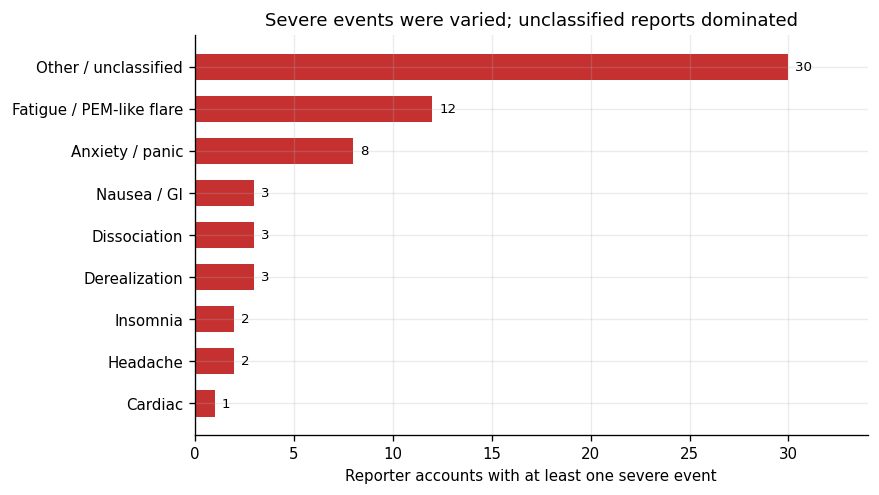

In [4]:
category_labels = {
    "other": "Other / unclassified",
    "fatigue_pem_flare": "Fatigue / PEM-like flare",
    "anxiety_panic": "Anxiety / panic",
    "nausea_gi": "Nausea / GI",
    "derealization": "Derealization",
    "dissociation": "Dissociation",
    "headache": "Headache",
    "insomnia": "Insomnia",
    "cardiac": "Cardiac",
}
plot_severe = severe_categories.copy()
plot_severe.index = [category_labels.get(x, x.replace("_", " ").title()) for x in plot_severe.index]
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.barh(plot_severe.index, plot_severe["reporters"], color="#c53030", height=0.62)
ax.set_xlabel("Reporter accounts with at least one severe event")
ax.set_title("Severe events were varied; unclassified reports dominated")
for yi, value in enumerate(plot_severe["reporters"]):
    ax.text(value + 0.35, yi, f"{value}", va="center", fontsize=8)
ax.set_xlim(0, 34)
fig.tight_layout()
plt.show()

**Plain-language verdict:** The leading named severe-event category was fatigue or a PEM-like flare (12 reporters), followed by anxiety or panic (8). Thirty reporters had severe events that did not fit the closed vocabulary. Category counts overlap because one account could report more than one event.

## What patients are saying

This public-facing notebook does not reproduce searchable Reddit quotations. At the aggregate level, accounts most often described improvement in mood or cognition, sometimes alongside no-effect or worsened symptoms; the mixed profiles above preserve that complexity. Source text was excluded from the analysis frames under the study's privacy contract.

## Conclusion

These accounts contain a real signal of enthusiasm: the model identified 282 reporters using language consistent with strong benefit, and psilocybin's mood/cognitive reports were particularly positive. Yet the same dataset warns against a simple success story. One in five effect-bearing reporter–drug pairs was mixed or conflicting, fatigue did not perform like mood/cognition, and the explicit PEM evidence was too thin to interpret.

For a patient audience, the defensible takeaway is that some users described substantial and occasionally durable benefits, while severe adverse experiences also occurred. The data support better prospective study of symptom-specific outcomes; they do not support choosing a drug, dose, or treatment setting.

## Research limitations

- **Selection:** participants were self-selected online posters already discussing these drugs.
- **Reporting:** unusual successes and harms may be more likely to be posted; silence is not “no event.”
- **Survivorship:** people able and motivated to post may differ from those lost to follow-up.
- **Recall:** retrospective accounts can misremember dose, timing, and response.
- **Confounding:** illness severity, indication, route, setting, and other treatments were not controlled.
- **No control group:** improvement cannot be separated from natural variation, placebo effects, or concurrent care.
- **Extracted language versus efficacy:** model labels are not validated clinical outcomes; positive labels may be over-called, and treatment lists can inflate attribution.
- **Temporal snapshot:** the dataset is a fixed 2026 snapshot and underlying post dates were unavailable.

Additional constraints include sparse dose and duration data, unverified identity at the Reddit-account level, no human validation of this extraction run, and drug arms that differ substantially in reported route and context.

In [5]:
provenance = P.provenance_table(DB_PATH, f).set_index("item")["value"]
provenance_summary = pd.DataFrame({
    "Item": [
        "Database", "Database SHA-256", "Pinned run ID", "Source snapshot date",
        "Content date range", "Included claims", "Effect records",
        "Adverse-event records", "Skill version", "Execution date (UTC)"
    ],
    "Value": [
        provenance["database"], provenance["database SHA-256"], provenance["run ID (pinned)"],
        provenance["source snapshot date"], provenance["content date range"],
        f"{len(u.claims):,}", f"{len(u.effects):,}", f"{len(u.adverse):,}",
        provenance["skill version"], provenance["execution date (UTC)"]
    ]
})
display(HTML("<h3>Provenance</h3>"))
display(provenance_summary.style.hide(axis="index").set_properties(**{"text-align": "left"}))
display(HTML(
    '<p style="font-size:1.2em;font-weight:bold;font-style:italic;margin-top:1.5em">'
    'These findings reflect reporting patterns in online communities, not population-level treatment effects. '
    'This is not medical advice.</p>'
))

Item,Value
Database,psychedelic_pharmacology.db
Database SHA-256,2edbe6136ec8c451e486ecd3d3b19cbdf1ed2e78e47a07c5a808f8cf137f96cc
Pinned run ID,710567555e22b68c025d8ceb1c3373564d7f9b01dcc5fe94b02b7c3209ecbc05
Source snapshot date,2026-06-13 (the date in the snapshot name)
Content date range,unavailable — post timestamps are not loaded
Included claims,"2,921"
Effect records,"2,890"
Adverse-event records,472
Skill version,research-assistant v2
Execution date (UTC),2026-08-11
